In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
ti = sns.load_dataset("titanic")

In [3]:
features = ["pclass", "sex", "age", "fare","embarked" ]
target = ["survived"]

In [4]:
from sklearn.impute import SimpleImputer
mean_val = SimpleImputer(strategy="median")
ti[["age"]] = mean_val.fit_transform(ti[["age"]])
frequent_val = SimpleImputer(strategy="most_frequent")
ti[["embarked"]] = frequent_val.fit_transform(ti[["embarked"]])

In [5]:
#encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ti["sex"] = le.fit_transform(ti["sex"])
ti["embarked"] = le.fit_transform(ti["embarked"])

In [6]:
X = ti[features]
y = ti["survived"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# dicision tree

In [9]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

model.fit(X_train, y_train)
y_pre = model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score
print("accuracy_score : ", accuracy_score( y_test, y_pre) )

accuracy_score :  0.770949720670391


[Text(0.5, 0.875, 'sex <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]\nclass = Died'),
 Text(0.25, 0.625, 'pclass <= 2.5\ngini = 0.386\nsamples = 245\nvalue = [64, 181]\nclass = survived'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'age <= 2.5\ngini = 0.074\nsamples = 130\nvalue = [5, 125]\nclass = survived'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'fare <= 23.35\ngini = 0.5\nsamples = 115\nvalue = [59.0, 56.0]\nclass = Died'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'age <= 6.5\ngini = 0.303\nsamples = 467\nvalue = [380, 87]\nclass = Died'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'pclass <= 2.5\ngini = 0.434\nsamples = 22\nvalue = [7.0, 15.0]\nclass = survived'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'pclass <= 1.5\ngini = 0.271\nsamples = 445\nvalue = [373, 72]\nclass = Died'),
 Tex

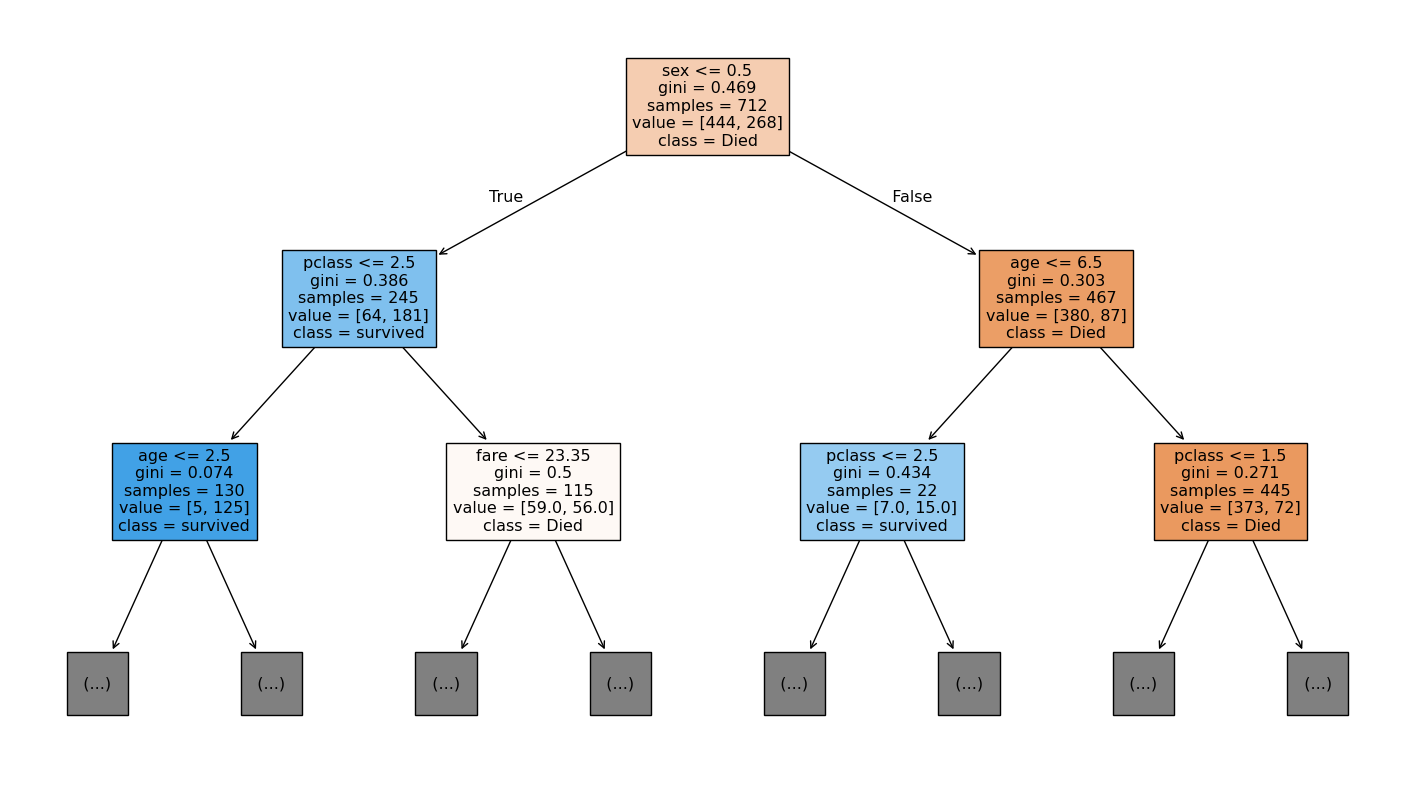

In [11]:
from sklearn.tree  import plot_tree
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "survived"],
    filled=True,
    max_depth=2
    
)

# bagging classifier

In [12]:
from sklearn.ensemble import BaggingClassifier
base_model = DecisionTreeClassifier()
bag_cls = BaggingClassifier(
    base_model,
    n_estimators=201
)

bag_cls.fit(X_train, y_train)
y_pre = bag_cls.predict(X_test)
print("accuracy_score : ", accuracy_score( y_test, y_pre) )

accuracy_score :  0.8044692737430168


In [13]:
from sklearn.linear_model import LogisticRegression
base_model = LogisticRegression()
bag_cls = BaggingClassifier(
    base_model,
    n_estimators=201
)

bag_cls.fit(X_train, y_train)
y_pre = bag_cls.predict(X_test)
print("accuracy_score : ", accuracy_score( y_test, y_pre) )

accuracy_score :  0.7988826815642458


# bagging regresion

# boosting 

# 1. gradient boosting 

# 1. regression 

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, accuracy_score
from sklearn.datasets import make_regression

In [49]:
X, y = make_regression(
    n_samples=1000,
    n_features=10,
    noise=20,
    random_state=42
)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

In [34]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.13,
    max_depth=5,
    random_state=42
    
)
gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.13
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [35]:
y_preee = gbr.predict(X_test)

In [36]:
r2_score(y_preee, y_test)

0.8417083815163473

In [37]:
gbr.score(X_test, y_test)

0.8862987917014643

# classifier 

In [53]:
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42 
)

In [55]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=100,
    random_state=42,
    max_depth=5
    
)

In [56]:
gbc.fit(X_train, y_train)
yp = gbc.predict(X_test) 

In [58]:
gbc.score(X_test, y_test)
accuracy_score(y_test, yp)

0.9366666666666666